In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import os
import pandas as pd

In [2]:
# find max F1-Score and corresponding AUC, PR-AUC and Loss for each run
folder_path = "/Users/andreasstampedalgaard/Fagprojekt_Modeling_the_structure_of_DNA/results"
results = []

for dimension in [2, 3, 8, 16, 32]:
    for weighting in [True, False]:
        for run in range(1, 11):
            file_name = f"{dimension}_weighting_{weighting}_run{run}.csv"
            file_path = os.path.join(folder_path, file_name)
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                max_f1_score = df["F1-Score"].max()
                max_index = df["F1-Score"].idxmax()
                corresponding_auc = df.loc[max_index, "AUC"]
                corresponding_pr_auc = df.loc[max_index, "PR-AUC"]
                corresponding_loss = df.loc[max_index, "Loss"]
                results.append({
                    "Dimension": dimension,
                    "Weighting": weighting,
                    "Run": run,
                    "Max F1-Score": max_f1_score,
                    "Corresponding AUC": corresponding_auc,
                    "Corresponding PR-AUC": corresponding_pr_auc,
                    "Corresponding Loss": corresponding_loss
                })
# convert results to DataFrame
results_df = pd.DataFrame(results)

In [3]:
results_df

,Dimension,Weighting,Run,Max F1-Score,Corresponding AUC,Corresponding PR-AUC,Corresponding Loss
0,2,True,1,0.752716,0.833326,0.823337,0.827607
1,2,True,2,0.753067,0.833594,0.823540,0.827619
2,2,True,3,0.753075,0.833667,0.823613,0.827645
3,2,True,4,0.752837,0.833346,0.823046,0.827596
4,2,True,5,0.753078,0.833586,0.823501,0.827714
...,...,...,...,...,...,...,...
95,32,False,6,0.755405,0.836239,0.825250,0.363304
96,32,False,7,0.755530,0.836456,0.825483,0.363013
97,32,False,8,0.755608,0.836528,0.825332,0.363239
98,32,False,9,0.755482,0.836321,0.825270,0.362617


In [4]:
# find mean and std of max F1-Score, AUC, PR-AUC and Loss for each dimension and weighting
summary = results_df.groupby(["Dimension", "Weighting"]).agg({
    "Max F1-Score": ["mean", "std"],
    "Corresponding AUC": ["mean", "std"],
    "Corresponding PR-AUC": ["mean", "std"],
    "Corresponding Loss": ["mean", "std"]
}).reset_index()
summary.columns = ["Dimension", "Weighting", "F1-Score Mean", "F1-Score Std", "AUC Mean", "AUC Std", "PR-AUC Mean", "PR-AUC Std", "Loss Mean", "Loss Std"]
summary

,Dimension,Weighting,F1-Score Mean,F1-Score Std,AUC Mean,AUC Std,PR-AUC Mean,PR-AUC Std,Loss Mean,Loss Std
0,2,False,0.752268,0.000179,0.832471,0.000222,0.822992,0.000293,0.369936,0.000011
1,2,True,0.752901,0.000145,0.833430,0.000140,0.823292,0.000207,0.827638,0.000044
2,3,False,0.754498,0.000087,0.835312,0.000149,0.824894,0.000150,0.367605,0.000017
3,3,True,0.754635,0.000101,0.835663,0.000089,0.824705,0.000120,0.821394,0.000136
4,8,False,0.755786,0.000118,0.836950,0.000094,0.826018,0.000119,0.365078,0.000018
5,8,True,0.755848,0.000171,0.837180,0.000184,0.826045,0.000217,0.814357,0.000056
6,16,False,0.755590,0.000161,0.836607,0.000129,0.825366,0.000123,0.363479,0.000199
7,16,True,0.755235,0.000126,0.836412,0.000143,0.825436,0.000195,0.814114,0.002663
8,32,False,0.755482,0.000089,0.836368,0.000113,0.825365,0.000144,0.363167,0.000220
9,32,True,0.755515,0.000169,0.836663,0.000131,0.825602,0.000124,0.814158,0.000850


In [5]:
# conduct t-tests between weighting and no weighting for each dimension and store the results in a dataframe
t_test_results = []
for dimension in [2, 3, 8, 16, 32]:
    weighting_group = results_df[(results_df["Dimension"] == dimension) & (results_df["Weighting"] == True)]["Max F1-Score"]
    no_weighting_group = results_df[(results_df["Dimension"] == dimension) & (results_df["Weighting"] == False)]["Max F1-Score"]
    t_stat, p_value = ttest_ind(weighting_group, no_weighting_group)
    t_test_results.append({"Dimension": dimension, "T-statistic": t_stat, "P-value": p_value})
t_test_results_df = pd.DataFrame(t_test_results)
t_test_results_df

,Dimension,T-statistic,P-value
0,2,8.674015,7.601214e-08
1,3,3.243663,4.507894e-03
2,8,0.954229,3.526078e-01
3,16,-5.463770,3.441261e-05
4,32,0.558669,5.832713e-01


In [6]:
# conduct t-test between dimensions for weighting and no weighting separately and store the results in a dataframe
dimension_t_test_results = []
for weighting in [True, False]:
    for i in range(len([2, 3, 8, 16, 32])):
        for j in range(i + 1, len([2, 3, 8, 16, 32])):
            dimension_i_group = results_df[(results_df["Dimension"] == [2, 3, 8, 16, 32][i]) & (results_df["Weighting"] == weighting)]["Max F1-Score"]
            dimension_j_group = results_df[(results_df["Dimension"] == [2, 3, 8, 16, 32][j]) & (results_df["Weighting"] == weighting)]["Max F1-Score"]
            t_stat, p_value = ttest_ind(dimension_i_group, dimension_j_group)
            dimension_t_test_results.append({
                "Weighting": weighting,
                "Dimension i": [2, 3, 8, 16, 32][i],
                "Dimension j": [2, 3, 8, 16, 32][j],
                "T-statistic": t_stat,
                "P-value": p_value
            })
dimension_t_test_results_df = pd.DataFrame(dimension_t_test_results)
dimension_t_test_results_df

,Weighting,Dimension i,Dimension j,T-statistic,P-value
0,True,2,3,-31.006535,4.473920e-17
1,True,2,8,-41.569709,2.450544e-19
2,True,2,16,-38.317878,1.045334e-18
3,True,2,32,-37.127870,1.832115e-18
4,True,3,8,-19.362240,1.684117e-13
5,True,3,16,-11.752775,7.050455e-10
6,True,3,32,-14.173723,3.313767e-11
7,True,8,16,9.120230,3.613081e-08
8,True,8,32,4.387588,3.550800e-04
9,True,16,32,-4.195819,5.432406e-04


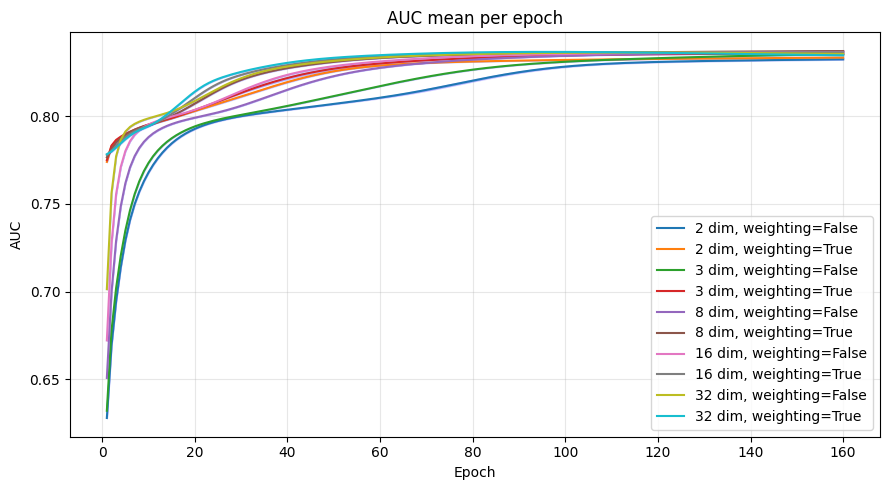

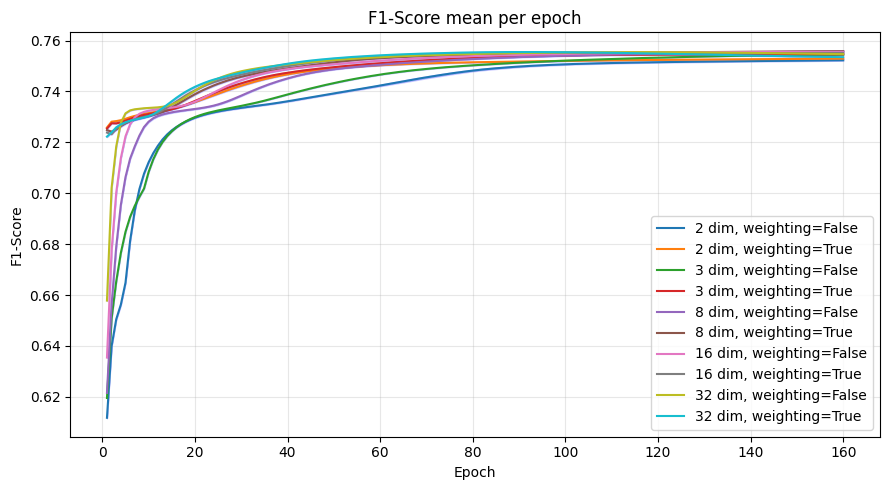

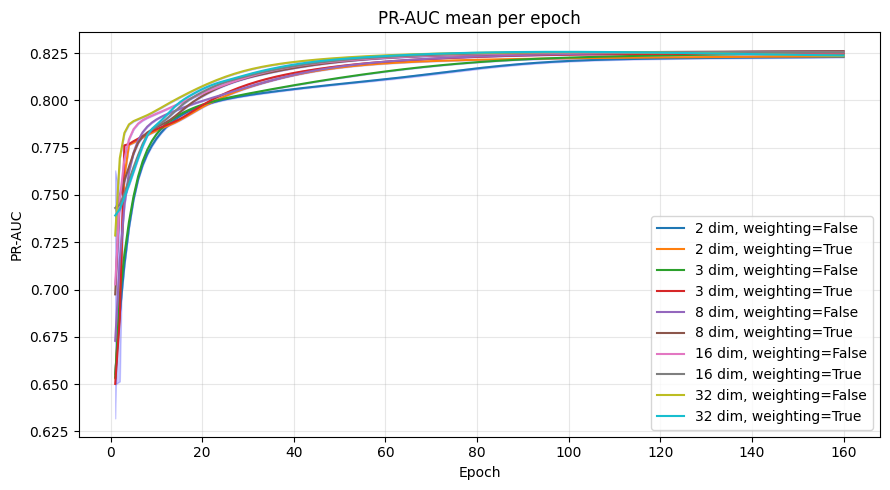

In [12]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

folder = Path("/Users/andreasstampedalgaard/Fagprojekt_Modeling_the_structure_of_DNA/results")  # folder with your CSV files
metrics = ["AUC", "F1-Score", "PR-AUC"]

pattern = re.compile(r"(?P<dim>\d+)_weighting_(?P<weighting>True|False)_run(?P<run>\d+)\.csv")

all_runs = []

for file in folder.glob("*_weighting_*_run*.csv"):
    match = pattern.match(file.name)
    if not match:
        continue

    df = pd.read_csv(file)
    df["epoch"] = df.index + 1
    df["run"] = int(match.group("run"))
    df["dim"] = int(match.group("dim"))
    df["weighting"] = match.group("weighting")

    all_runs.append(df[["dim", "weighting", "run", "epoch"] + metrics])

data = pd.concat(all_runs, ignore_index=True)

summary = (
    data
    .groupby(["dim", "weighting", "epoch"])[metrics]
    .agg(["mean", "std"])
    .reset_index()
)

summary.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in summary.columns
]

for metric in metrics:
    plt.figure(figsize=(9, 5))

    for (dim, weighting), group in summary.groupby(["dim", "weighting"]):
        group = group.sort_values("epoch")

        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"

        label = f"{dim} dim, weighting={weighting}"

        plt.plot(
            group["epoch"],
            group[mean_col],
            label=label
        )

        plt.fill_between(
            group["epoch"],
            group[mean_col] - group[std_col],
            group[mean_col] + group[std_col],
            alpha=0.2,
            color="blue"
        )

    plt.title(f"{metric} mean per epoch")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(f"{metric}_mean_per_epoch.png", dpi=300)
    plt.show()